Paso 1: Definición del Problema y Justificación del Proyecto
1.1 Contexto del Negocio
En un mercado saturado de opciones alimenticias, el Nutri-Score se ha consolidado como la herramienta estándar en Europa para empoderar al consumidor. Sin embargo, la base de datos colaborativa más grande del mundo, Open Food Facts, enfrenta un desafío: miles de productos carecen de una etiqueta oficial validada debido a la lentitud de los procesos de certificación o la falta de datos completos por parte de los fabricantes pequeños.

1.2 Declaración del Problema (Problem Statement)
¿Cómo podemos garantizar que el consumidor tome decisiones saludables cuando la información oficial no está disponible?
La ausencia de etiquetas Nutri-Score en una gran parte del catálogo genera una brecha de información que favorece el consumo de productos ultraprocesados no identificados.

1.3 Objetivo del Proyecto
Desarrollar un modelo de Machine Learning capaz de automatizar la clasificación Nutri-Score con una precisión superior al 85%. El sistema debe actuar como un motor de inferencia que, a partir de la composición química y nutricional (macronutrientes), asigne una calificación de la A a la E.

1.4 Propuesta Tecnológica: ¿Por qué XGBoost?
Se ha seleccionado el algoritmo XGBoost Classifier debido a:

Manejo de relaciones no lineales: El cálculo del Nutri-Score real utiliza un sistema de puntos con umbrales específicos que los árboles de decisión capturan con precisión quirúrgica.

Robustez ante datos tabulares: Es el algoritmo estado del arte para este volumen de registros (86,000+).

Importancia de variables: Permite auditar qué nutrientes (como azúcares o grasas saturadas) están penalizando más la nota, aportando transparencia al modelo.

1.5 Impacto Esperado
Completitud de Datos: Etiquetar automáticamente productos huérfanos en Open Food Facts.

Escalabilidad: Procesar nuevos lanzamientos de productos en milisegundos.

Salud Pública: Proporcionar una herramienta visual e inmediata para que el usuario final identifique la calidad nutricional.

In [2]:
# Paso 2 Carga de datos

import pandas as pd

def load_data_massive(target_min=85000):
    url = "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz"
    cols = [
        'product_name', 'nutriscore_grade', 'energy-kcal_100g', 'fat_100g',
        'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
        'fiber_100g', 'proteins_100g', 'salt_100g', 'sodium_100g'
    ]

    chunk_list = []
    total_cleaned = 0
    chunk_size = 100000 # Leemos de 100k en 100k

    print("Iniciando búsqueda masiva de datos...")

    # Usamos iterator=True para procesar el archivo por partes
    reader = pd.read_csv(url, sep='\t', usecols=cols, compression='gzip',
                         chunksize=chunk_size, low_memory=False)

    for i, chunk in enumerate(reader):
        # Limpieza rápida en el chunk actual
        chunk = chunk.dropna(subset=['nutriscore_grade'])
        chunk = chunk[chunk['nutriscore_grade'].isin(['a', 'b', 'c', 'd', 'e'])]

        # Opcional: filtrar los que tengan al menos energía y azúcares
        chunk = chunk.dropna(subset=['energy-kcal_100g', 'sugars_100g'])

        chunk_list.append(chunk)
        total_cleaned += len(chunk)

        print(f"Iteración {i+1}: Acumulados {total_cleaned} registros válidos...")

        if total_cleaned >= target_min:
            print("--- ¡Objetivo alcanzado! ---")
            break

    return pd.concat(chunk_list)

# Ejecutamos la nueva carga
df_massive = load_data_massive(85000)


Iniciando búsqueda masiva de datos...
Iteración 1: Acumulados 7324 registros válidos...
Iteración 2: Acumulados 15775 registros válidos...
Iteración 3: Acumulados 22434 registros válidos...
Iteración 4: Acumulados 38124 registros válidos...
Iteración 5: Acumulados 46340 registros válidos...
Iteración 6: Acumulados 56365 registros válidos...
Iteración 7: Acumulados 68452 registros válidos...
Iteración 8: Acumulados 77144 registros válidos...
Iteración 9: Acumulados 83234 registros válidos...
Iteración 10: Acumulados 89066 registros válidos...
--- ¡Objetivo alcanzado! ---


In [3]:
# Paso 2.1 Almacenamiento en SQL

import sqlite3
conn = sqlite3.connect('proyecto_final.db')

# IMPORTANTE: Reemplazamos la tabla con los datos masivos
df_massive.to_sql('raw_food', conn, if_exists='replace', index=False)

# Verificamos con una consulta rápida
res = pd.read_sql_query("SELECT count(*) as total FROM raw_food", conn)
print(f"Total final en SQL: {res['total'][0]}")
conn.close()

Total final en SQL: 89066


/tmp/ipykernel_14611/735164570.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='nutriscore_grade', data=df_eda, palette='RdYlGn_r', order=['a', 'b', 'c', 'd', 'e'])


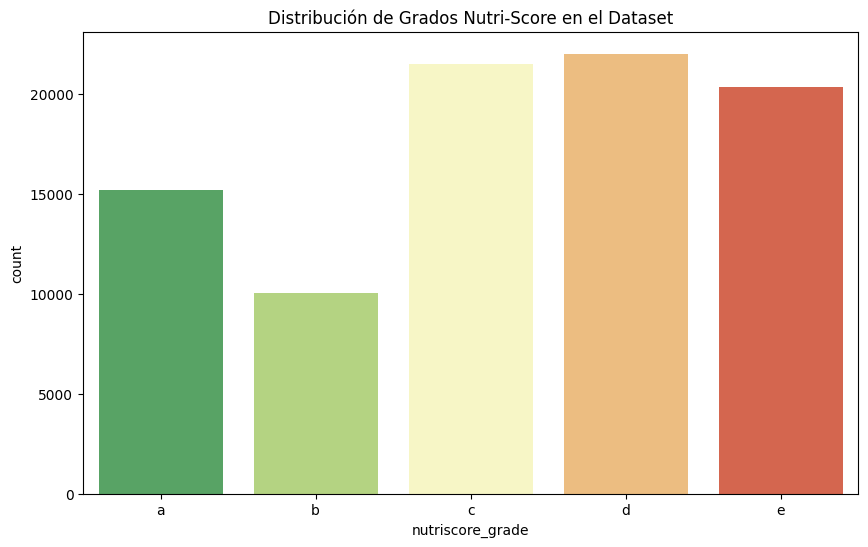

In [4]:
# Paso 3. EDA

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sqlite3

# Recuperamos los datos de SQL para el análisis
conn = sqlite3.connect('proyecto_final.db')
df_eda = pd.read_sql_query("SELECT * FROM raw_food", conn)
conn.close()

# Graficamos la distribución
plt.figure(figsize=(10, 6))
sns.countplot(x='nutriscore_grade', data=df_eda, palette='RdYlGn_r', order=['a', 'b', 'c', 'd', 'e'])
plt.title('Distribución de Grados Nutri-Score en el Dataset')
plt.show()


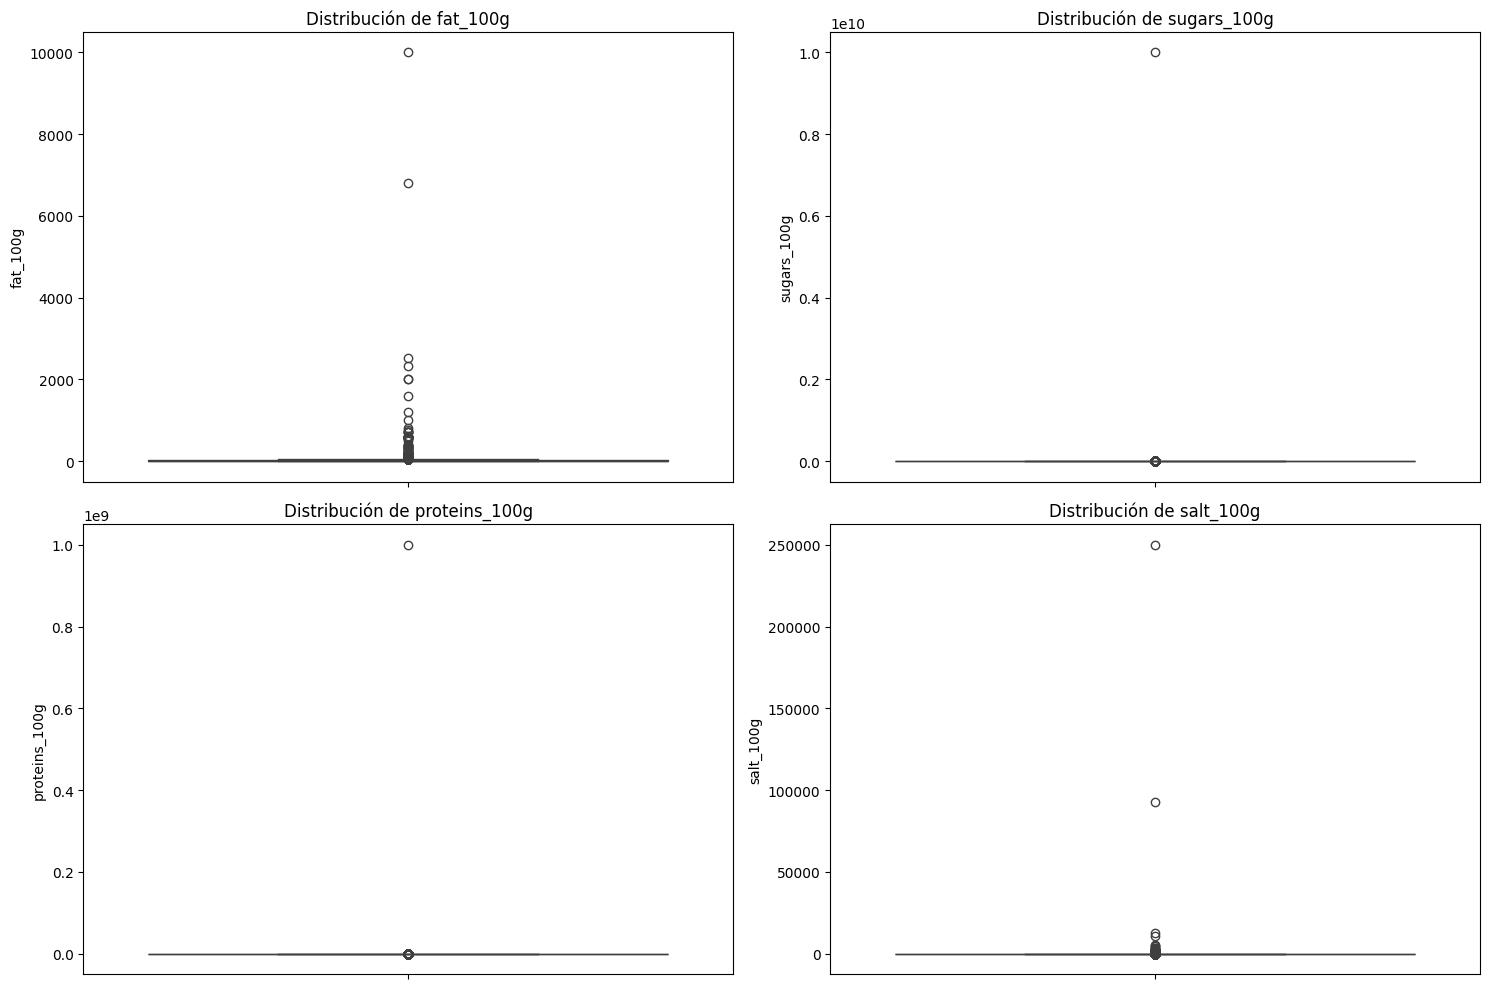

In [5]:
# Lista de variables numéricas a revisar
nutri_cols = ['fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']

plt.figure(figsize=(15, 10))
for i, col in enumerate(nutri_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df_eda[col])
    plt.title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

In [6]:
def prepare_model_data(df):
    # 1. LIMPIEZA FÍSICA
    # Eliminamos valores imposibles (> 100g o < 0g)
    for col in ['fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']:
        df = df[(df[col] >= 0) & (df[col] <= 100)]

    # La suma de macros no puede exceder los 100g (aprox)
    df = df[(df['fat_100g'] + df['carbohydrates_100g'] + df['proteins_100g']) <= 105]

    # 2. FEATURE ENGINEERING (Para llegar a las 20 variables)
    df = df.copy()

    # Proporciones numéricas (6 variables nuevas)
    df['sugar_ratio'] = df['sugars_100g'] / (df['carbohydrates_100g'] + 0.1)
    df['sat_fat_ratio'] = df['saturated-fat_100g'] / (df['fat_100g'] + 0.1)
    df['protein_ratio'] = df['proteins_100g'] / (df['fat_100g'] + df['carbohydrates_100g'] + df['proteins_100g'] + 0.1)
    df['salt_density'] = df['salt_100g'] / (df['energy-kcal_100g'] + 1)
    df['carb_minus_sugar'] = df['carbohydrates_100g'] - df['sugars_100g']
    df['total_solids'] = df['fat_100g'] + df['carbohydrates_100g'] + df['proteins_100g'] + df['salt_100g']

    # Booleanas/Categóricas (5 variables nuevas)
    beverage_keywords = 'juice|soda|water|drink|beverage|leche|milk|jugo|refresco|tea|coffee'
    df['is_beverage'] = df['product_name'].str.contains(beverage_keywords, case=False, na=False).astype(int)
    df['is_high_sugar'] = (df['sugars_100g'] > 15).astype(int)
    df['is_high_fat'] = (df['fat_100g'] > 20).astype(int)
    df['is_high_salt'] = (df['salt_100g'] > 1.5).astype(int)
    df['is_low_cal'] = (df['energy-kcal_100g'] < 40).astype(int)

    # 3. ENCODING DEL TARGET
    target_map = {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4}
    df['target'] = df['nutriscore_grade'].str.lower().map(target_map)
    df = df.dropna(subset=['target']) # Por si acaso quedó algún 'unknown'

    return df

# Ejecución:
df_final = prepare_model_data(df_eda)
print(f"Registros listos: {len(df_final)}")
print(f"Columnas totales: {len(df_final.columns)}")

Registros listos: 86974
Columnas totales: 23


In [7]:
# 1. Definimos la lista oficial de las 20 variables predictoras
features_20 = [
    # Básicas (9)
    'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
    'carbohydrates_100g', 'sugars_100g', 'fiber_100g',
    'proteins_100g', 'salt_100g', 'sodium_100g',

    # Ingeniería de Proporciones (6)
    'sugar_ratio', 'sat_fat_ratio', 'protein_ratio',
    'salt_density', 'carb_minus_sugar', 'total_solids',

    # Categóricas/Booleanas (5)
    'is_beverage', 'is_high_sugar', 'is_high_fat',
    'is_high_salt', 'is_low_cal'
]

# 2. Creamos X (variables) y y (objetivo)
X = df_final[features_20]
y = df_final['target']

# 3. División de datos (80% entrenamiento, 20% prueba)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Estructura de X: {X.shape} (¡20 variables confirmadas!)")

Estructura de X: (86974, 20) (¡20 variables confirmadas!)


In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# Configuración del modelo con la métrica sugerida por el profesor
final_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.2,
    objective='multi:softprob', # Cambiamos a softprob para obtener probabilidades
    eval_metric='mlogloss',        # AUC para clasificación multiclase
    random_state=42
)

final_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [9]:
# 1. Obtenemos las probabilidades de cada clase
y_probs = final_model.predict_proba(X_test)

# 2. Calculamos el AUC Multiclase (One-vs-Rest)
# 'ovr' compara cada clase contra el resto, ideal para datos desbalanceados
auc_score = roc_auc_score(y_test, y_probs, multi_class='ovr', average='weighted')

print(f"El AUC-ROC del modelo es: {round(auc_score, 4)}")

El AUC-ROC del modelo es: 0.9881


In [10]:
from xgboost import XGBClassifier # Posible cambio
from sklearn.metrics import classification_report

# Configuramos el modelo
final_model = XGBClassifier(
    subsample=1.0,
    n_estimators=200,
    max_depth=8,
    learning_rate=0.2,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=5,
    random_state=42
)

# Entrenamos el "Campeón"
final_model.fit(X_train, y_train)

# Predicción y Evaluación
y_pred = final_model.predict(X_test)

print("\n--- REPORTE FINAL DEL MODELO (20 VARIABLES) ---")
print(classification_report(y_test, y_pred))


--- REPORTE FINAL DEL MODELO (20 VARIABLES) ---
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2959
           1       0.79      0.76      0.78      1965
           2       0.87      0.89      0.88      4245
           3       0.91      0.92      0.92      4340
           4       0.96      0.94      0.95      3886

    accuracy                           0.90     17395
   macro avg       0.89      0.88      0.89     17395
weighted avg       0.90      0.90      0.90     17395



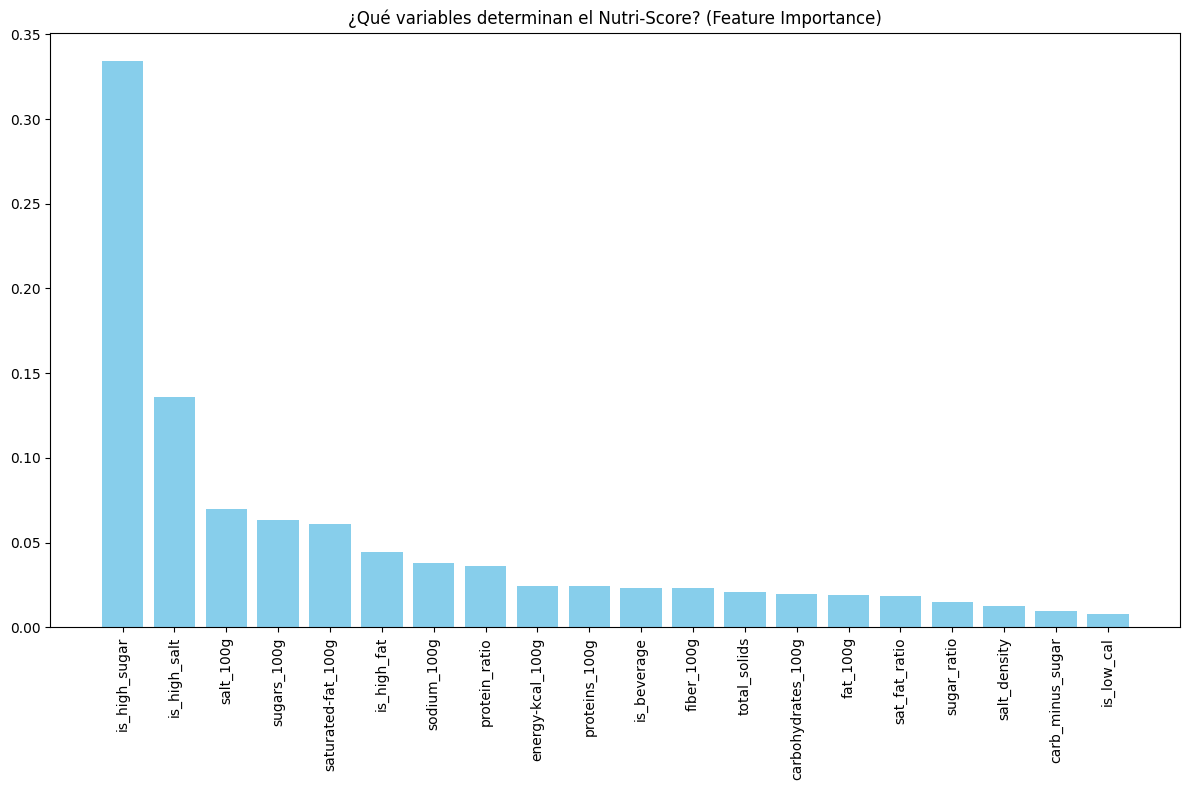

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Extraer la importancia de las variables
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Graficar
plt.figure(figsize=(12, 8))
plt.title("¿Qué variables determinan el Nutri-Score? (Feature Importance)")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='skyblue')
plt.xticks(range(X.shape[1]), [features_20[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

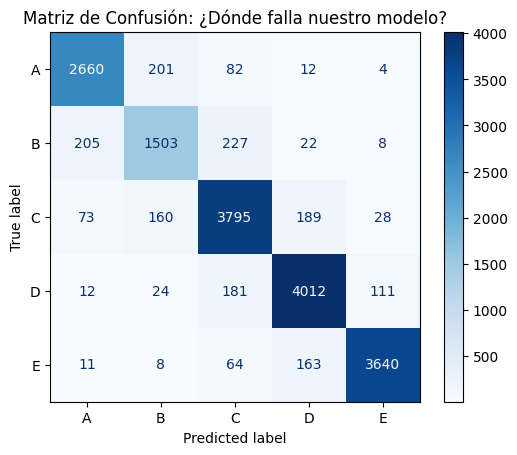

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ensure y_pred is defined by making a prediction
y_pred = final_model.predict(X_test)

# Generar la matriz
cm = confusion_matrix(y_test, y_pred)
classes = ['A', 'B', 'C', 'D', 'E']

# Graficar
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión: ¿Dónde falla nuestro modelo?')
plt.show()

In [18]:
import joblib

# 1. Guardamos el modelo "campeón" entrenado
joblib.dump(final_model, 'nutriscore_xgb_model.pkl')

# 2. Guardamos la lista de las 20 variables
# Esto es CRUCIAL: la App debe recibir los datos en el mismo orden exacto
joblib.dump(features_20, 'features_list.pkl')

print("¡Archivos serializados con éxito!")

¡Archivos serializados con éxito!


In [19]:
from google.colab import files

# Descarga los archivos a tu carpeta local
files.download('nutriscore_xgb_model.pkl')
files.download('features_list.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>